# Predicted force & torque — noise EDA

How noisy is the BEM's **predicted** force/torque output? Data: `processed_data/bem/bem_<ID>_seg_X.csv` (no header, 35 cols = 29 merged + 6 predicted). Cols 30-35 = predicted force x/y/z [N], torque x/y/z [Nm] (FLU body frame; verified in `simulator.cpp:56-59`, `Readme.md:72-77`).

Noise = **SNR (dB)** = `10*log10(var(lowpass_25) / var(residual))`. Dimensionless, so force and torque combine directly. **Lower = noisier.**

In [1]:
%load_ext autoreload
%autoreload 2
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import utils as u

u.PRED

['fx', 'fy', 'fz', 'tx', 'ty', 'tz']

## Per-flight SNR of the 6 predicted channels

SNR (dB) is dimensionless, so the 6 channels average directly (no normalization). Whole flight, segments concatenated. Lower SNR = noisier.

In [2]:
cache = 'pred_snr.csv'
if Path(cache).exists():
    snr = pd.read_csv(cache, index_col=0)
else:
    snr = pd.DataFrame({fid: {c: u.snr_db(u.load_bem_flight(fid)[c].to_numpy()) for c in u.PRED}
                        for fid in u.bem_flight_ids()}).T
    snr.to_csv(cache)
snr.shape

(95, 6)

In [3]:
score = snr.mean(axis=1).sort_values()
noisiest, calmest = score.index[0], score.index[-1]
print('noisiest (lowest SNR):', noisiest, '\ncalmest  (highest SNR):', calmest)
score

noisiest (lowest SNR): 2021-02-18-16-43-54 
calmest  (highest SNR): 2021-02-03-16-58-13


2021-02-18-16-43-54    31.971993
2021-02-05-14-19-34    35.362428
2021-02-23-14-33-04    36.839362
2021-02-18-17-09-50    37.342134
2021-02-23-14-41-07    37.573627
                         ...    
2021-02-05-15-04-42    46.692470
2021-02-18-17-03-20    47.341400
2021-02-23-10-50-42    47.417344
2021-02-23-10-52-00    47.618049
2021-02-03-16-58-13    47.896335
Length: 95, dtype: float64

## Plot noisiest vs calmest

In [4]:
def plot_pred(fid, title):
    df = u.load_bem_flight(fid)
    t = df['t'].to_numpy()
    fm, tm = u.measured(df.to_numpy())
    meas = np.column_stack([fm, tm])
    fig, ax = plt.subplots(3, 2, figsize=(12, 7), sharex=True)
    for i, c in enumerate(u.PRED):
        a = ax[i % 3, i // 3]
        a.plot(t, meas[:, i], lw=0.5, alpha=0.5, label='measured')
        a.plot(t, df[c].to_numpy(), lw=0.8, label='predicted')
        a.set_ylabel(c)
    ax[0, 0].set_title('force [N]'); ax[0, 1].set_title('torque [Nm]')
    ax[2, 0].set_xlabel('t [s]'); ax[2, 1].set_xlabel('t [s]')
    ax[0, 0].legend(loc='upper right', fontsize=7)
    fig.suptitle(title); fig.tight_layout()

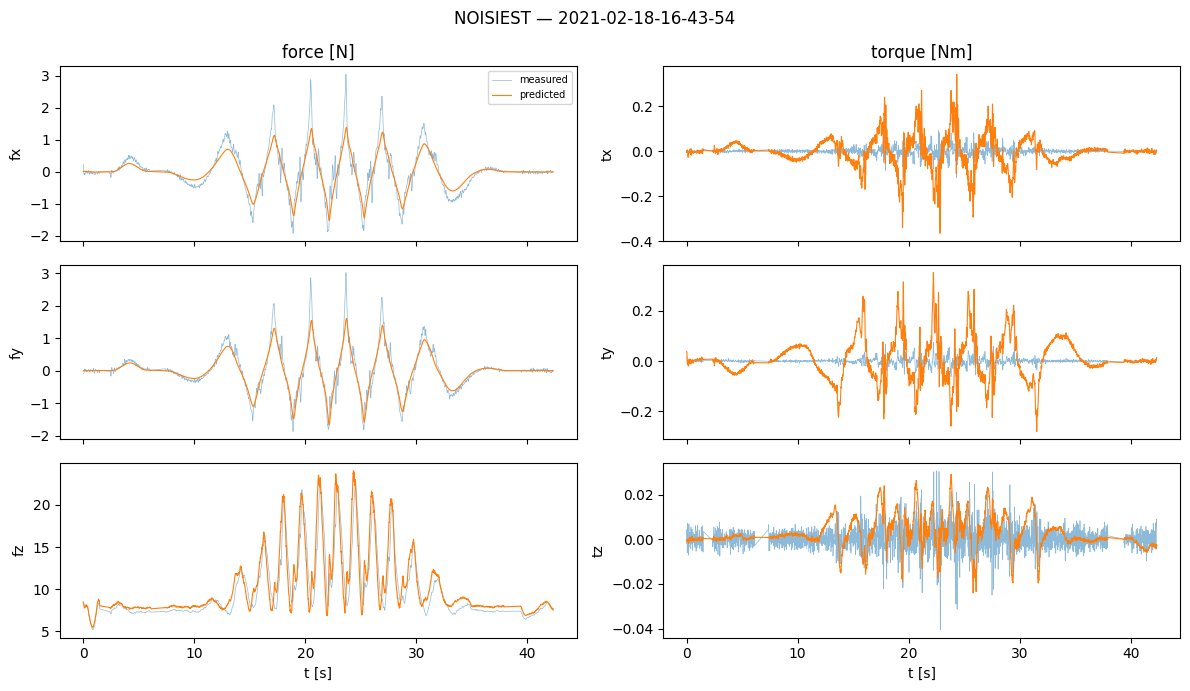

In [5]:
plot_pred(noisiest, f'NOISIEST — {noisiest}')

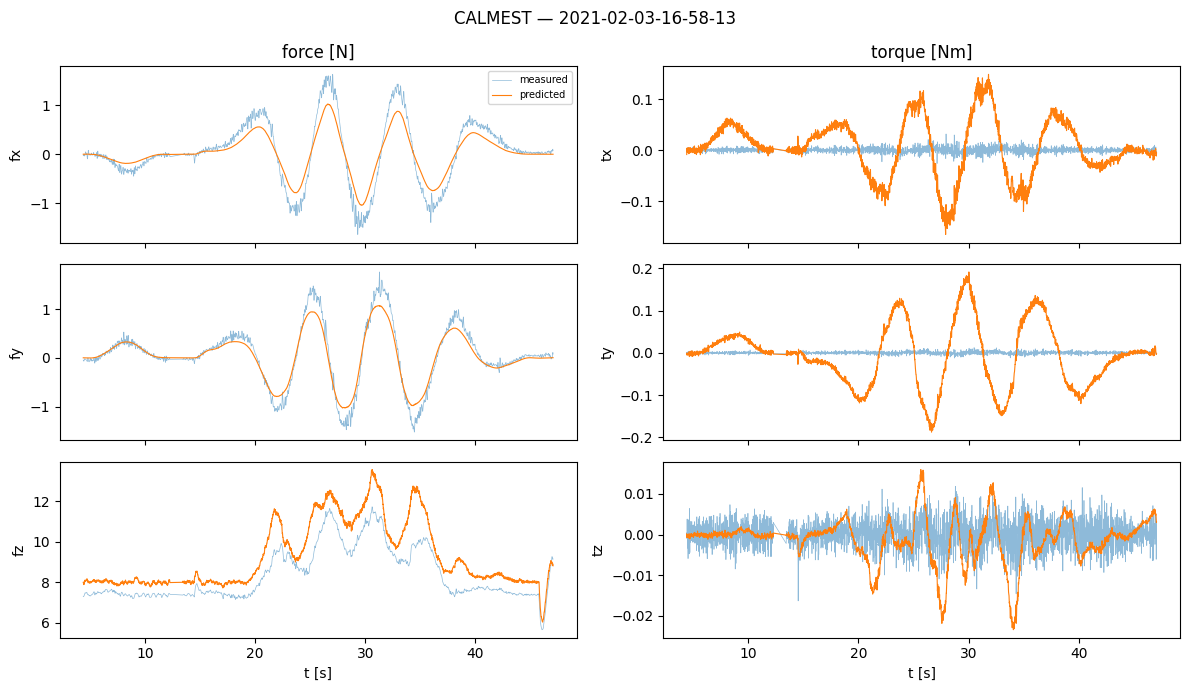

In [6]:
plot_pred(calmest, f'CALMEST — {calmest}')

## Best / worst flights by force & torque RMSE

RMSE of the residual (measured - predicted), magnitude over all 3 axes. Best = BEM predicts well; worst = BEM struggles. Measured via `utils.measured()`.

In [7]:
cache = 'pred_rmse.csv'
if Path(cache).exists():
    rmse = pd.read_csv(cache, index_col=0)
else:
    def flight_rmse(fid):
        fe, te = u.residuals(u.load_bem_flight(fid).to_numpy())
        return np.sqrt((fe ** 2).sum(1).mean()), np.sqrt((te ** 2).sum(1).mean())
    rmse = pd.DataFrame({fid: flight_rmse(fid) for fid in u.bem_flight_ids()},
                        index=['force_rmse', 'torque_rmse']).T
    rmse.to_csv(cache)
rmse.shape

(95, 2)

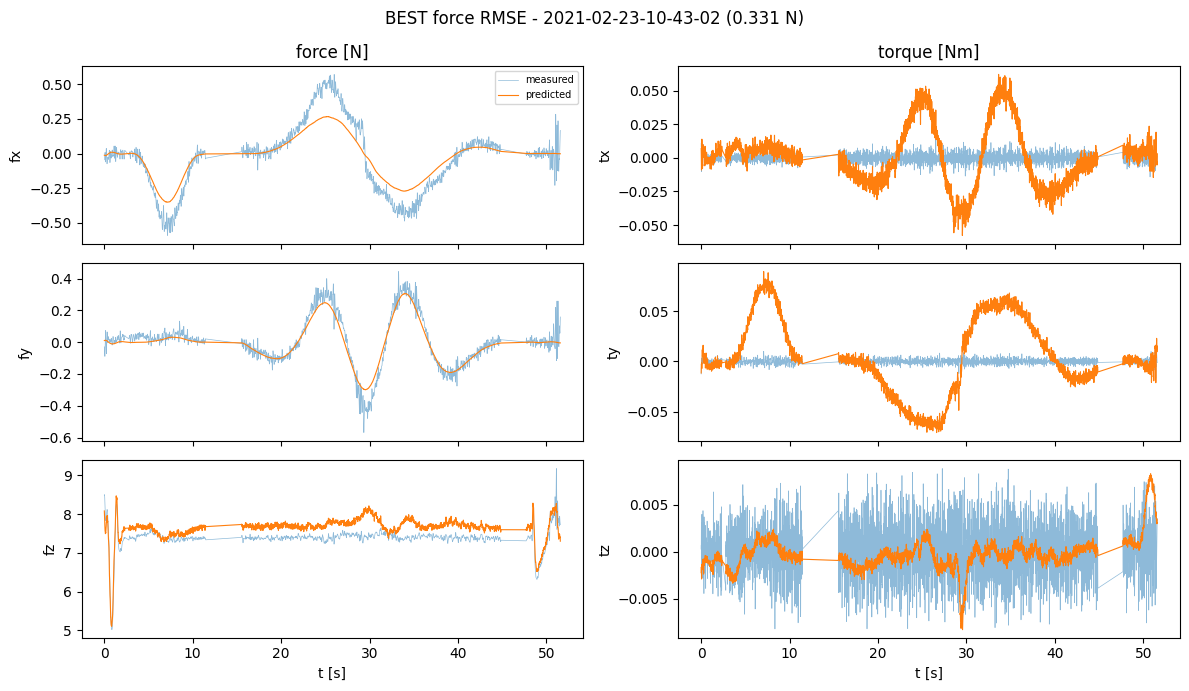

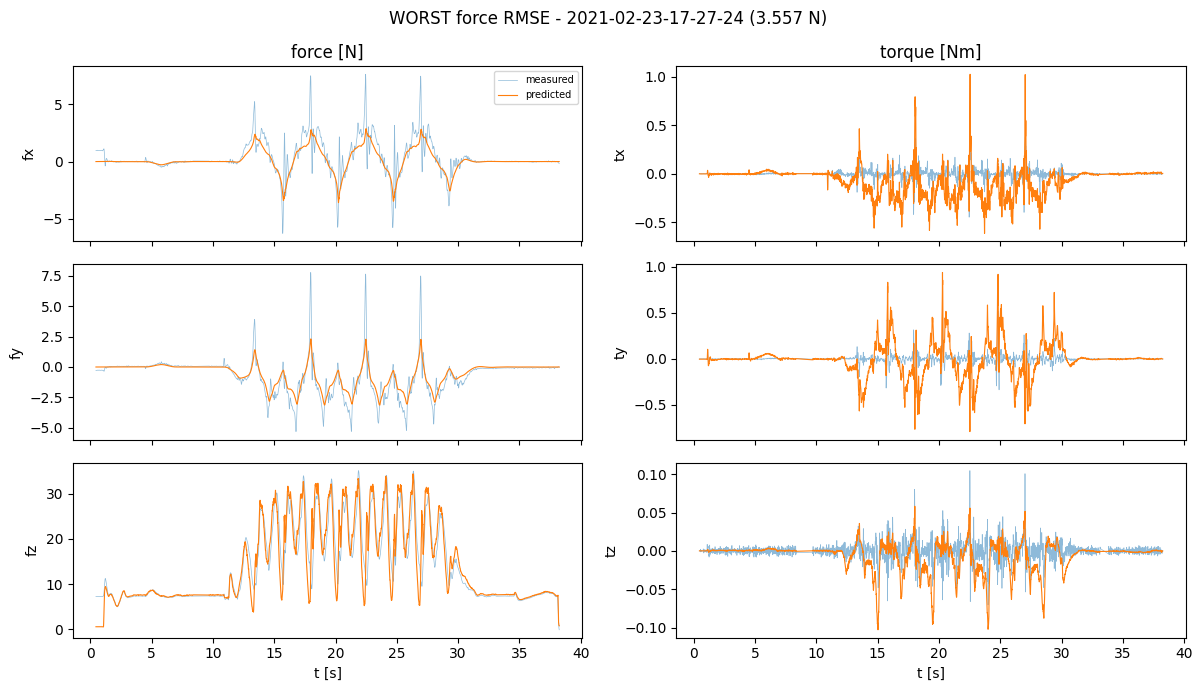

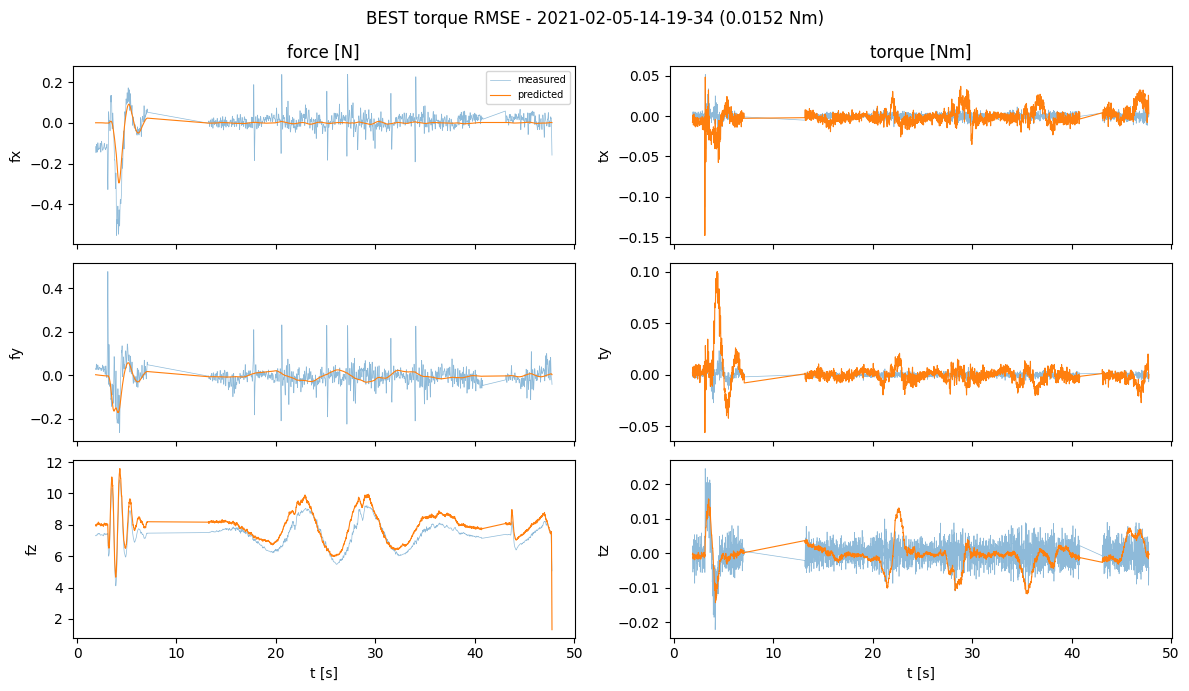

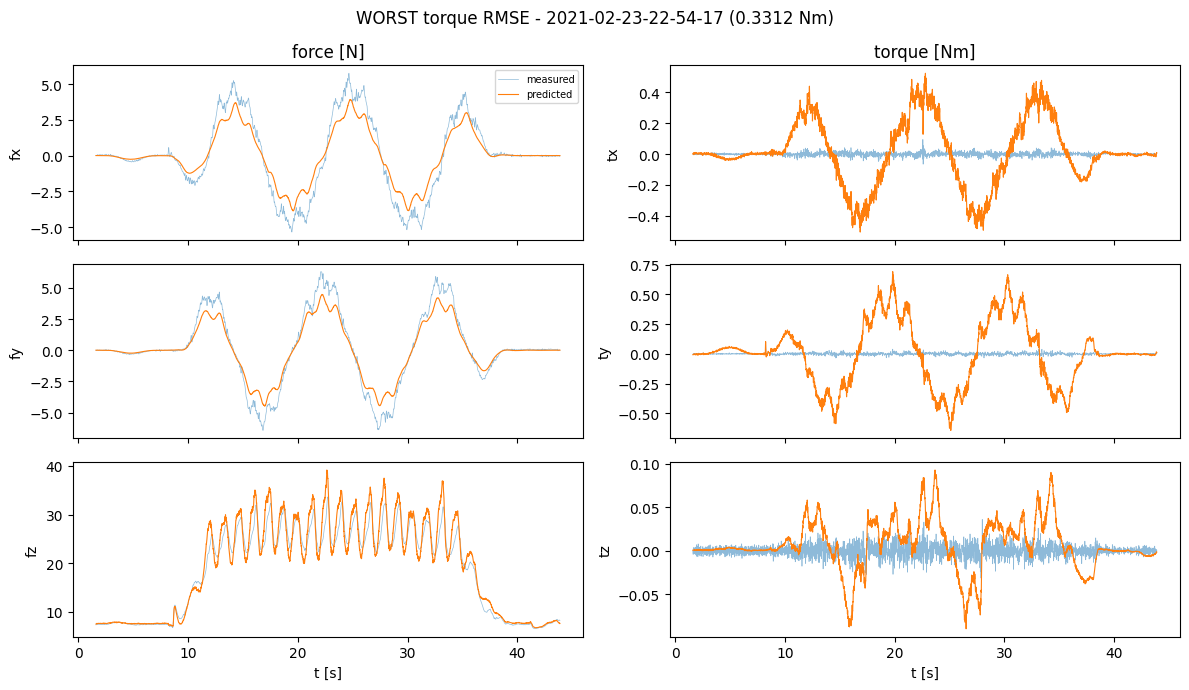

In [8]:
best_f, worst_f = rmse['force_rmse'].idxmin(), rmse['force_rmse'].idxmax()
best_t, worst_t = rmse['torque_rmse'].idxmin(), rmse['torque_rmse'].idxmax()
plot_pred(best_f,  f'BEST force RMSE - {best_f} ({rmse.loc[best_f, "force_rmse"]:.3f} N)')
plot_pred(worst_f, f'WORST force RMSE - {worst_f} ({rmse.loc[worst_f, "force_rmse"]:.3f} N)')
plot_pred(best_t,  f'BEST torque RMSE - {best_t} ({rmse.loc[best_t, "torque_rmse"]:.4f} Nm)')
plot_pred(worst_t, f'WORST torque RMSE - {worst_t} ({rmse.loc[worst_t, "torque_rmse"]:.4f} Nm)')